In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# %% [code]
import sys
from pathlib import Path

# Ensure project root is in path so Python can find src/stress_engine/
project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.stress_engine.monte_carlo import run_comprehensive_stress_engine

# Execute the 4D parametric stress engine (5,000 paths across 81 nodes)
# This writes the fresh parquet file to ../data/raw/synthetic_4d_monte_carlo_results.parquet
df_results = run_comprehensive_stress_engine(n_paths=5000, n_days=90)

# Display a clean preview of the freshly generated data
display(df_results.head(10))

Running 4D Stress Engine across 81 nodes (5000 paths each)...
Simulation complete in 3.37s. Saved to ../data/raw/synthetic_4d_monte_carlo_results.parquet


,Institution_Key,Volatility,Tail_Tier,Asymmetry,Shock_Severity,Mean_Max_DD,P95_Max_DD,Distress_Probability
0,Vol-Low_Tail-Fat_Asym-Low_Shock-Mild,Vol-Low,Tail-Fat,Asym-Low,Shock-Mild,-0.365466,-0.505300,0.3282
1,Vol-Low_Tail-Fat_Asym-Low_Shock-Mod,Vol-Low,Tail-Fat,Asym-Low,Shock-Mod,-0.363874,-0.507570,0.3150
2,Vol-Low_Tail-Fat_Asym-Low_Shock-Sev,Vol-Low,Tail-Fat,Asym-Low,Shock-Sev,-0.365311,-0.509436,0.3240
3,Vol-Low_Tail-Fat_Asym-Norm_Shock-Mild,Vol-Low,Tail-Fat,Asym-Norm,Shock-Mild,-0.364208,-0.505438,0.3176
4,Vol-Low_Tail-Fat_Asym-Norm_Shock-Mod,Vol-Low,Tail-Fat,Asym-Norm,Shock-Mod,-0.364774,-0.501562,0.3166
5,Vol-Low_Tail-Fat_Asym-Norm_Shock-Sev,Vol-Low,Tail-Fat,Asym-Norm,Shock-Sev,-0.364874,-0.508547,0.3130
6,Vol-Low_Tail-Fat_Asym-High_Shock-Mild,Vol-Low,Tail-Fat,Asym-High,Shock-Mild,-0.364845,-0.509509,0.3198
7,Vol-Low_Tail-Fat_Asym-High_Shock-Mod,Vol-Low,Tail-Fat,Asym-High,Shock-Mod,-0.364186,-0.508666,0.3154
8,Vol-Low_Tail-Fat_Asym-High_Shock-Sev,Vol-Low,Tail-Fat,Asym-High,Shock-Sev,-0.364870,-0.504783,0.3174
9,Vol-Low_Tail-Norm_Asym-Low_Shock-Mild,Vol-Low,Tail-Norm,Asym-Low,Shock-Mild,-0.366961,-0.511779,0.3282


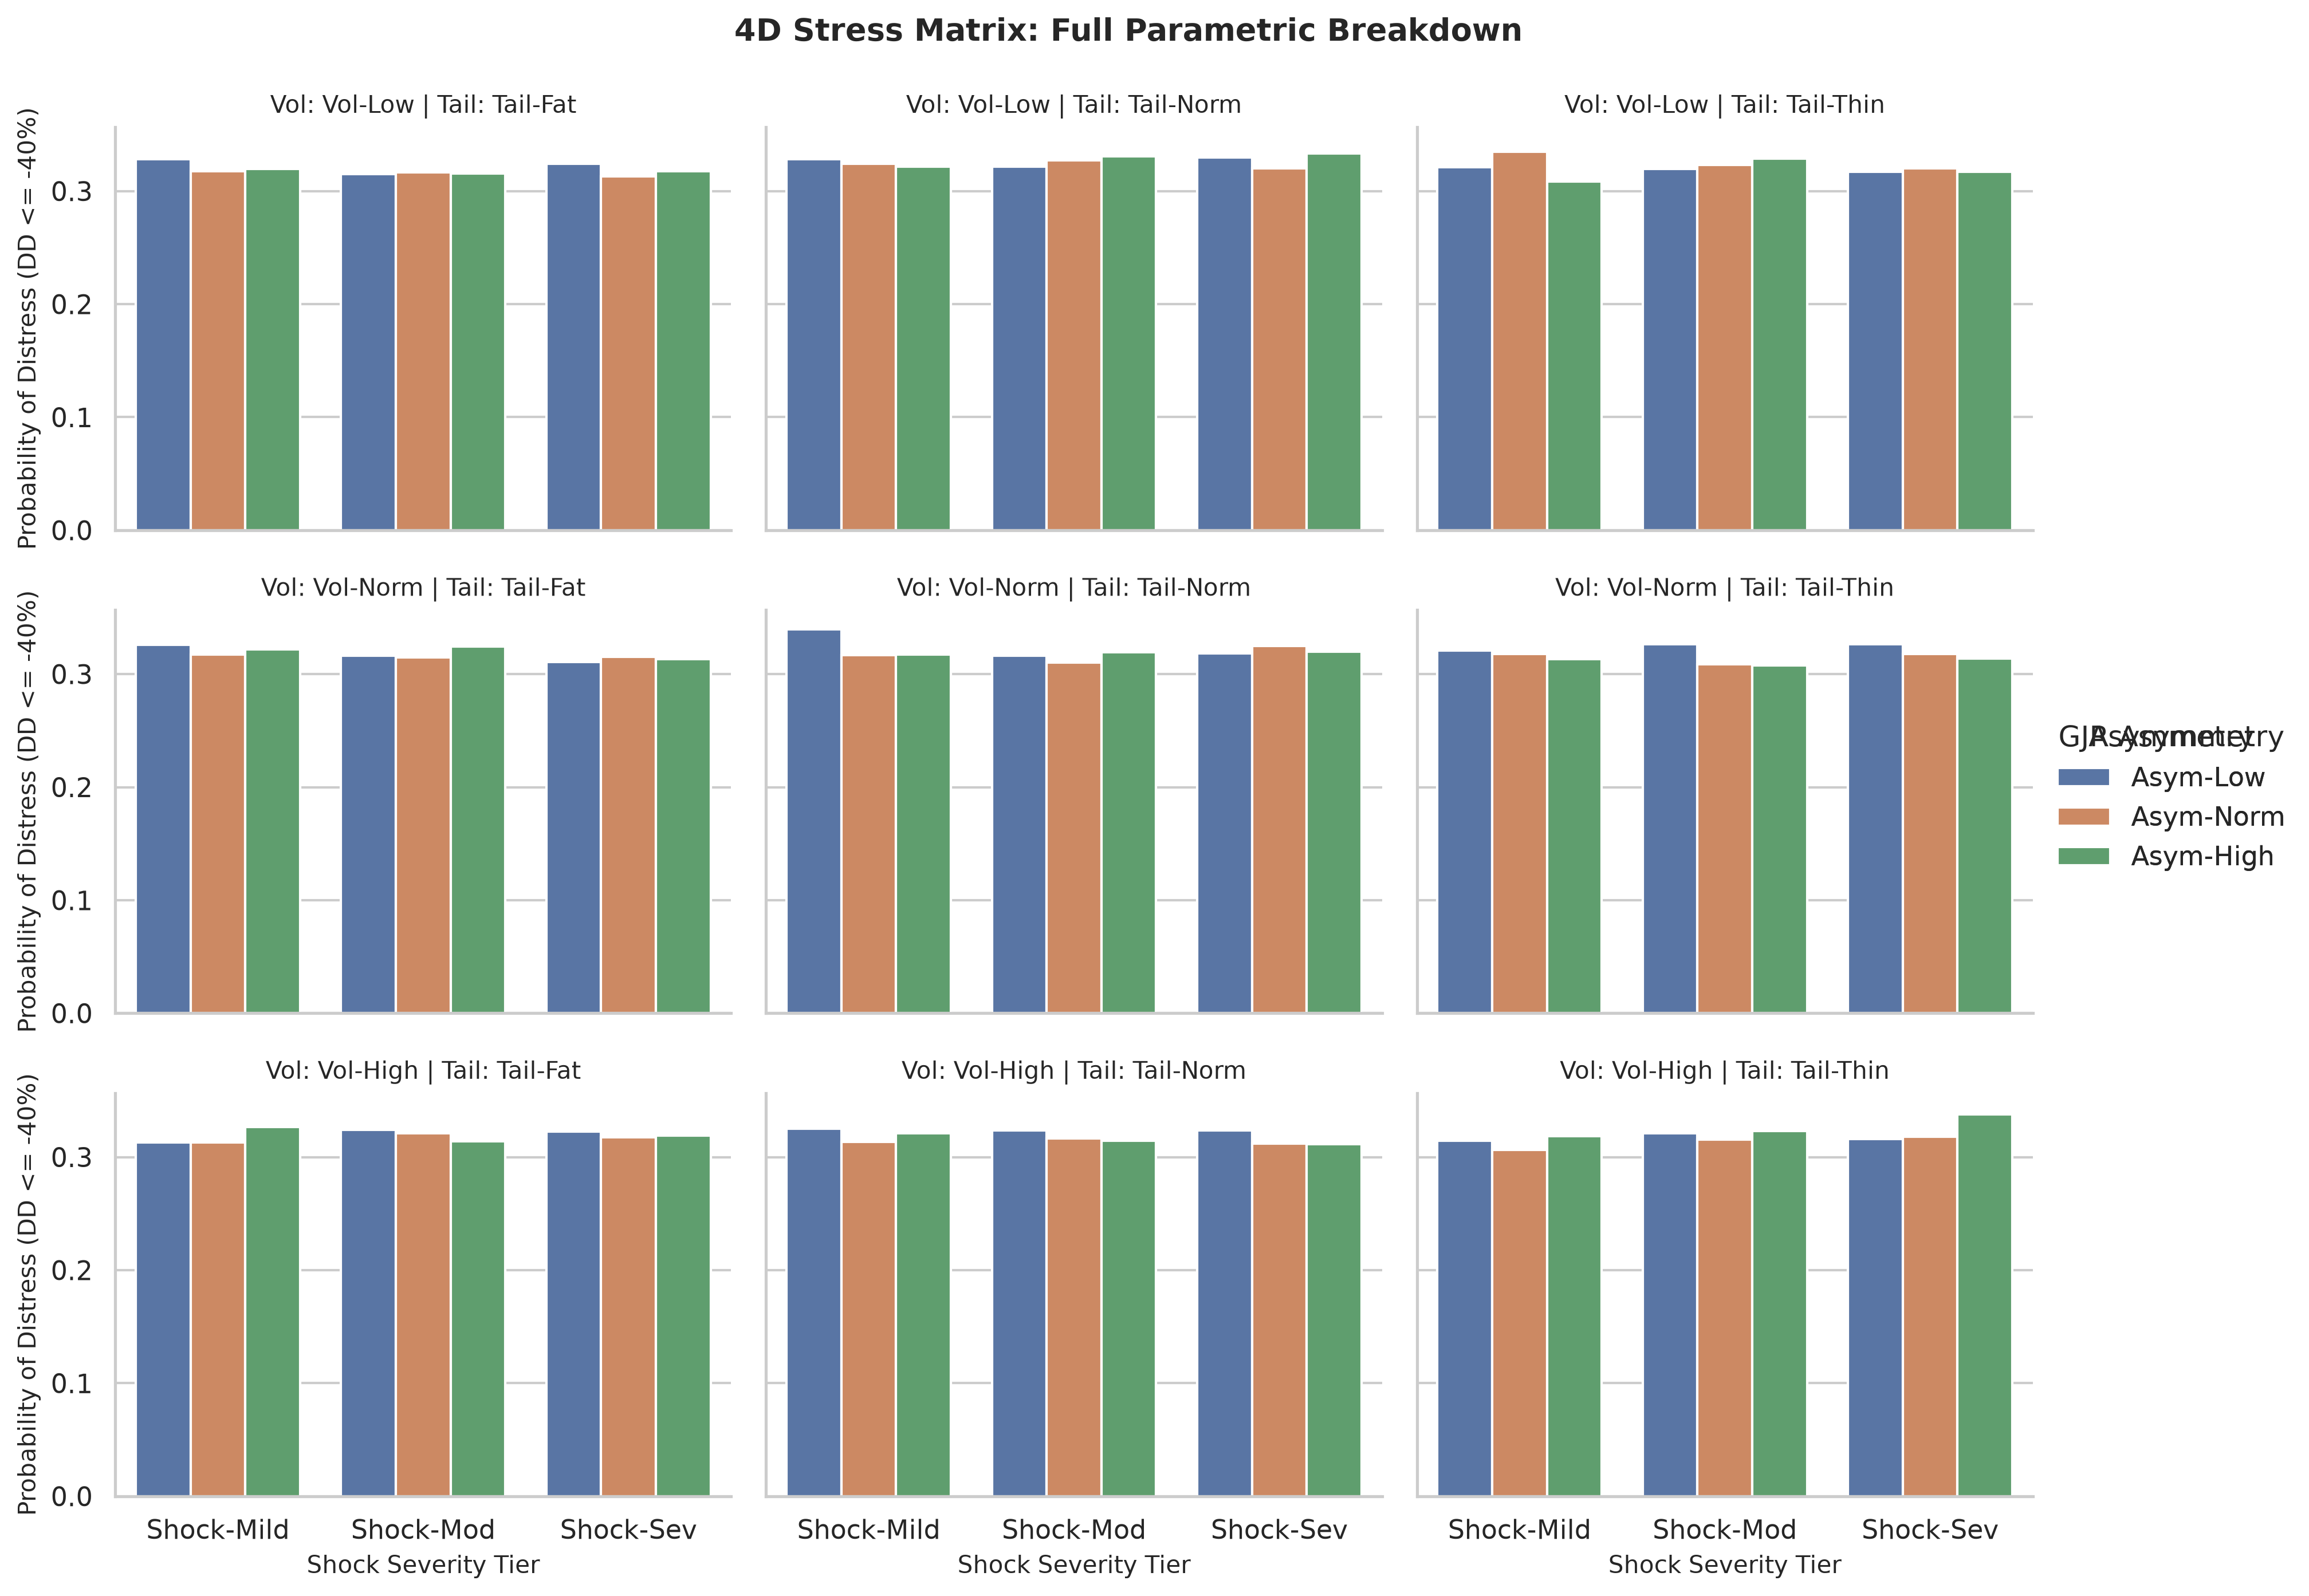

In [3]:
# %% [code]
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "axes.labelsize": 10,
        "axes.titlesize": 11,
    }
)

df_results = pd.read_parquet("../data/raw/synthetic_4d_monte_carlo_results.parquet")

# Ensure correct ordering of categorical tiers for clean visualization
shock_order = ["Shock-Mild", "Shock-Mod", "Shock-Sev"]
df_results["Shock_Severity"] = pd.Categorical(
    df_results["Shock_Severity"], categories=shock_order, ordered=True
)

# Build a clean 3x3 faceted bar chart where X=Shock, Hue=Asymmetry, Col=Tail, Row=Vol
g = sns.catplot(
    data=df_results,
    x="Shock_Severity",
    y="Distress_Probability",
    hue="Asymmetry",
    col="Tail_Tier",
    row="Volatility",
    kind="bar",
    height=3.0,
    aspect=1.2,
    palette="deep",
    sharey=True,
)

g.set_axis_labels("Shock Severity Tier", "Probability of Distress (DD <= -40%)")
g.set_titles(col_template="Tail: {col_name}", row_template="Vol: {row_name}")
g.add_legend(title="GJR Asymmetry")
g.fig.suptitle(
    "4D Stress Matrix: Full Parametric Breakdown",
    y=1.03,
    fontsize=13,
    fontweight="bold",
)

output_path = "../data/raw/stress_matrix_4d_grid.png"
plt.savefig(output_path, bbox_inches="tight")
plt.show()

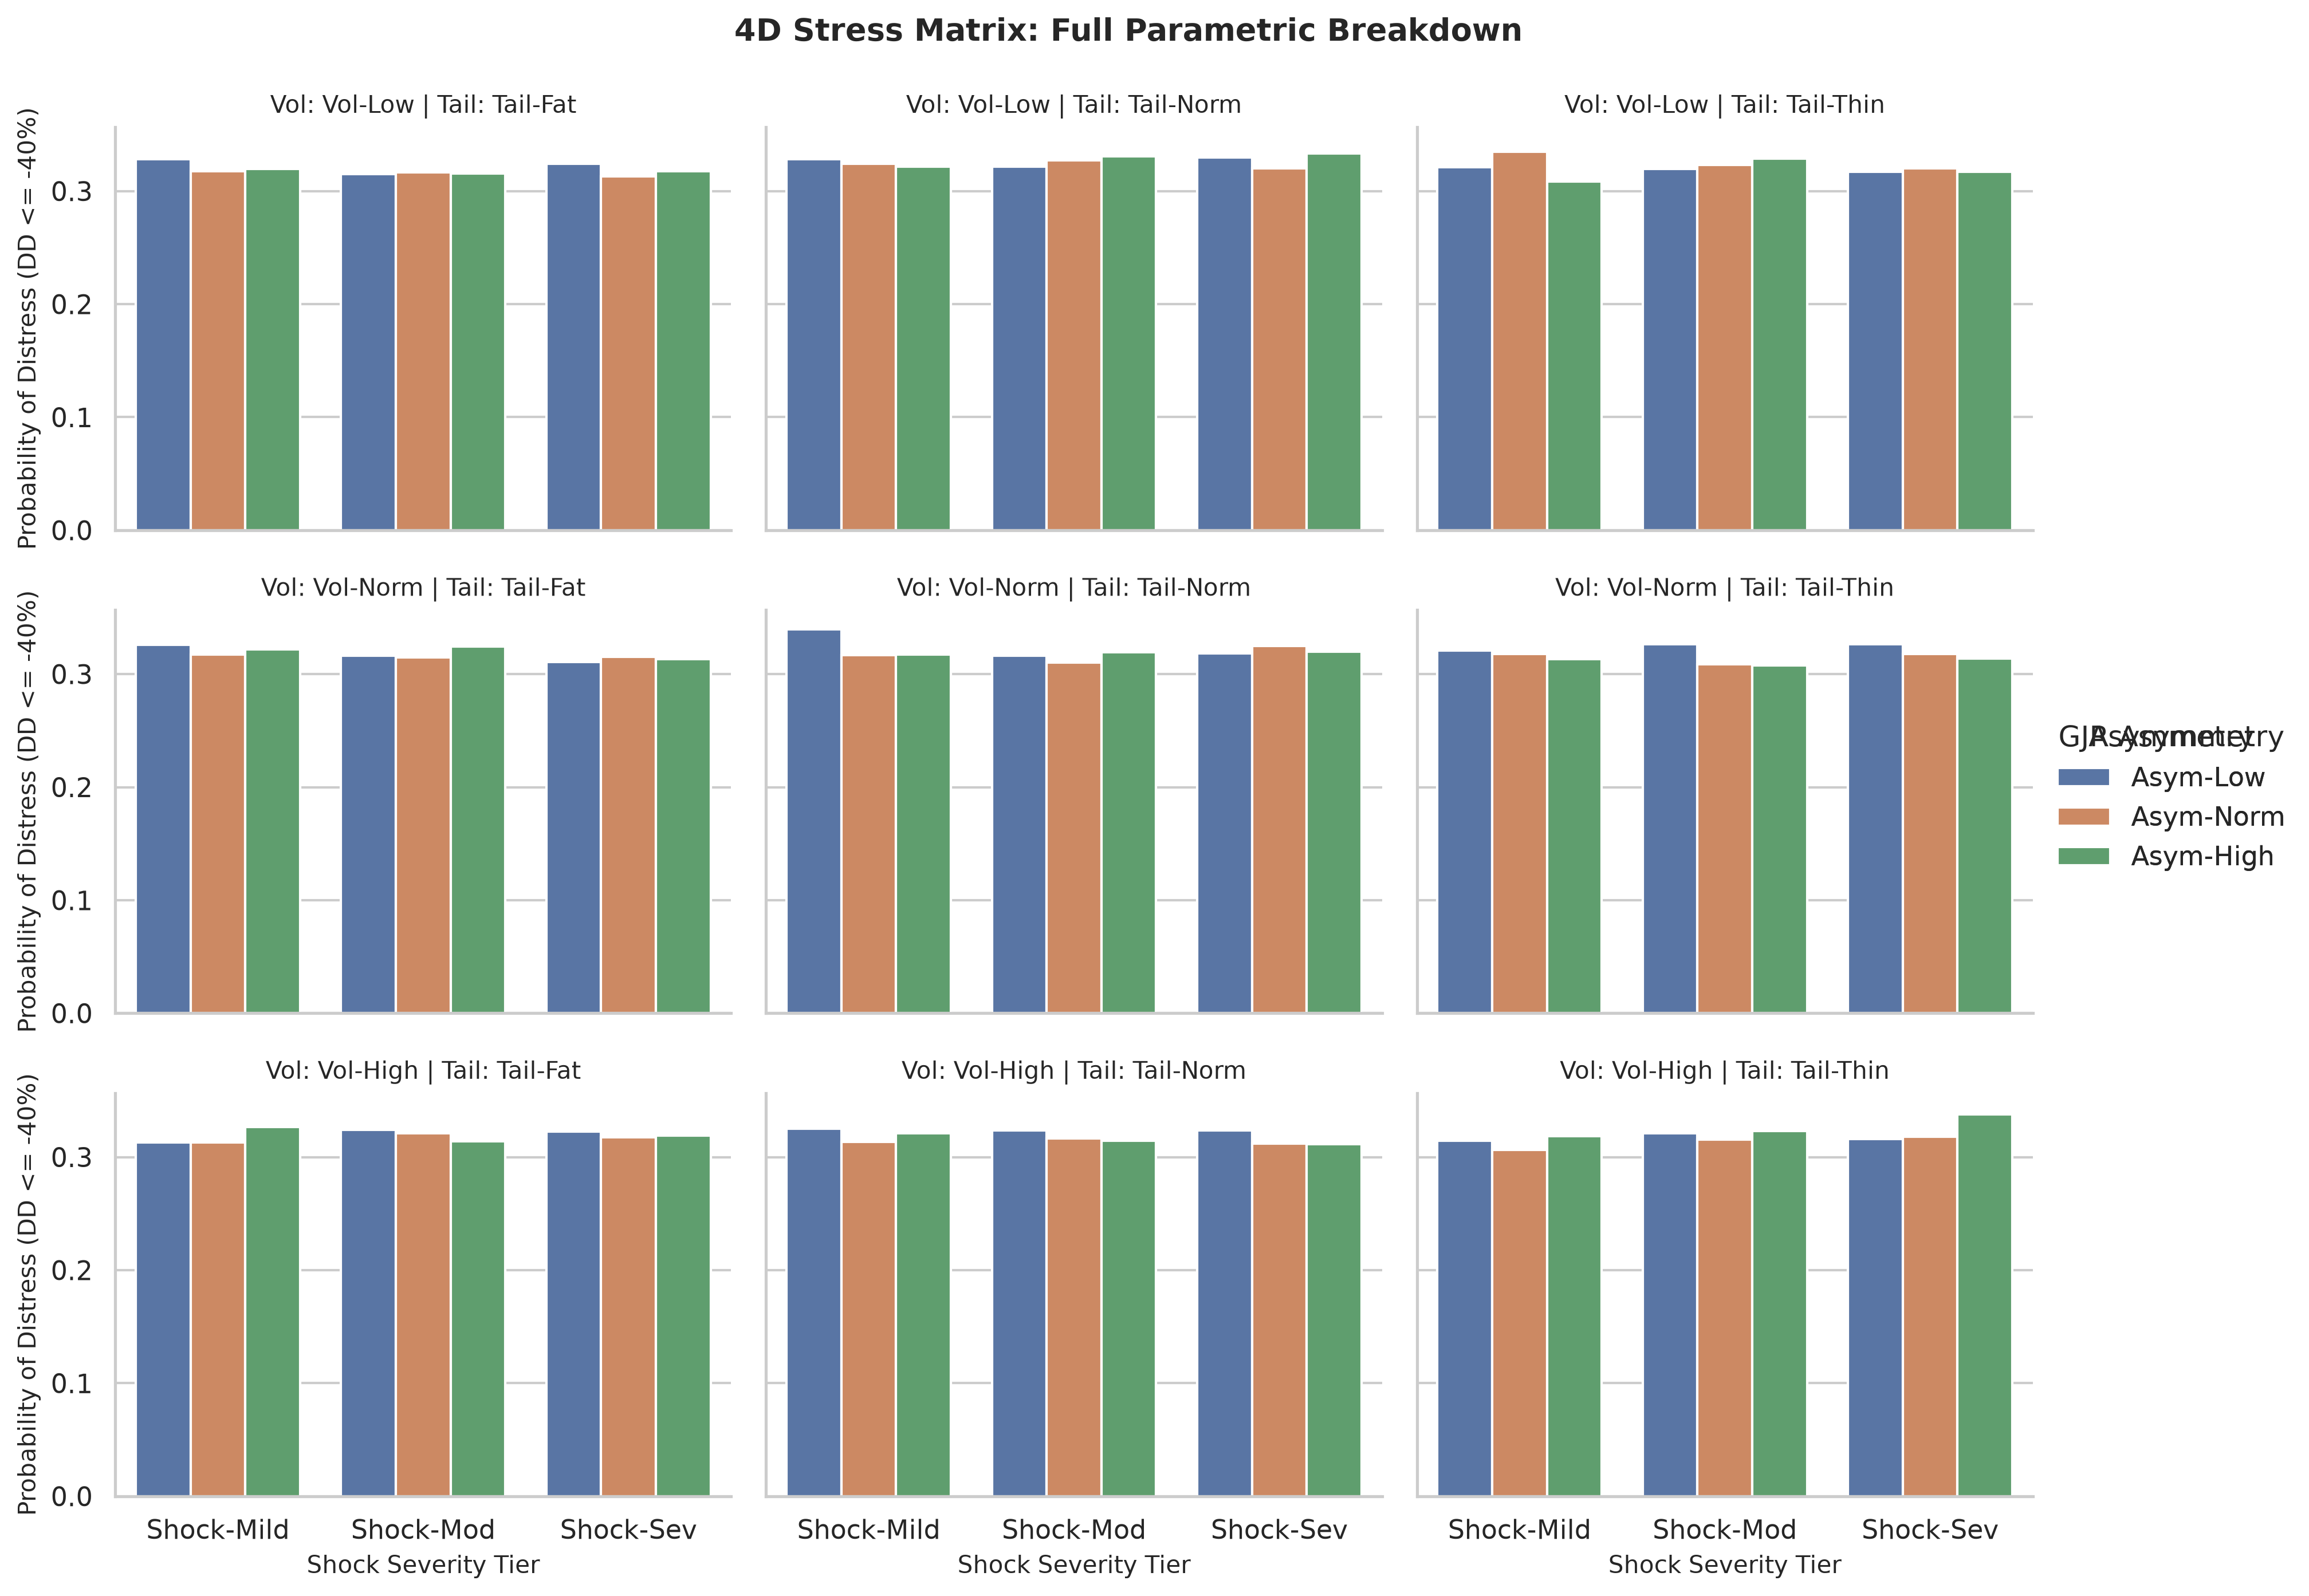

In [4]:
# %% [code]
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Set publication-grade styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "axes.labelsize": 10,
        "axes.titlesize": 11,
    }
)

# Load the freshly generated 4D parquet artifact
df_results = pd.read_parquet("../data/raw/synthetic_4d_monte_carlo_results.parquet")

# Ensure correct ordering of categorical tiers for clean visualization
shock_order = ["Shock-Mild", "Shock-Mod", "Shock-Sev"]
df_results["Shock_Severity"] = pd.Categorical(
    df_results["Shock_Severity"], categories=shock_order, ordered=True
)

# Build the 3x3 faceted bar chart directly in the notebook
g = sns.catplot(
    data=df_results,
    x="Shock_Severity",
    y="Distress_Probability",
    hue="Asymmetry",
    col="Tail_Tier",
    row="Volatility",
    kind="bar",
    height=3.0,
    aspect=1.2,
    palette="deep",
    sharey=True,
)

g.set_axis_labels("Shock Severity Tier", "Probability of Distress (DD <= -40%)")
g.set_titles(col_template="Tail: {col_name}", row_template="Vol: {row_name}")
g.add_legend(title="GJR Asymmetry")
g.fig.suptitle(
    "4D Stress Matrix: Full Parametric Breakdown",
    y=1.03,
    fontsize=13,
    fontweight="bold",
)

output_path = "../data/raw/stress_matrix_4d_grid.png"
plt.savefig(output_path, bbox_inches="tight")
plt.show()